# Importância de features sem enganação

**Tema:** Aprendizado Supervisionado › Bagging e Random Forest

Este notebook reproduz e aprofunda a armadilha de cardinalidade do tema 3
(módulo 3), agora com Random Forest, e compara MDI com importância por
permutação num cenário desenhado para expor a diferença: uma feature de
alta cardinalidade e ZERO relação real com o alvo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(44)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um dataset com gabarito conhecido: 4 úteis, 1 ruído de baixa
cardinalidade, 1 ruído de ALTA cardinalidade

In [2]:
n = 2000
uteis = rng.normal(size=(n, 4))
pesos_reais = np.array([2.0, -1.5, 1.0, 0.7])
logit = uteis @ pesos_reais
y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

ruido_baixa_card = rng.integers(0, 3, n)          # só 3 valores possíveis
ruido_alta_card = rng.integers(0, n, n)           # até n valores possíveis, PURO RUÍDO

X = pd.DataFrame(
    np.column_stack([uteis, ruido_baixa_card, ruido_alta_card]),
    columns=["util_1", "util_2", "util_3", "util_4", "ruido_baixa_card", "ruido_alta_card"])

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=0)
print(f"shape: {X.shape}")
print("gabarito: util_1..4 têm efeito real; as duas colunas de ruído não têm NENHUM.")

shape: (2000, 6)
gabarito: util_1..4 têm efeito real; as duas colunas de ruído não têm NENHUM.


## 2. Importância por impureza (MDI): o viés de cardinalidade aparece

In [3]:
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(X_treino, y_treino)
importancia_mdi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(
    ascending=False)

print("importância por MDI:")
print(importancia_mdi.round(4).to_string())
print(f"\nposição de 'ruido_alta_card' no ranking: "
      f"{list(importancia_mdi.index).index('ruido_alta_card') + 1} de {len(importancia_mdi)}")

importância por MDI:
util_1              0.3320
util_2              0.2353
util_3              0.1755
util_4              0.1357
ruido_alta_card     0.0959
ruido_baixa_card    0.0254

posição de 'ruido_alta_card' no ranking: 5 de 6


## 3. Importância por permutação, calculada no conjunto de TESTE

In [4]:
resultado_permutacao = permutation_importance(
    rf, X_teste, y_teste, n_repeats=30, random_state=0, scoring="roc_auc")

importancia_permutacao = pd.Series(
    resultado_permutacao.importances_mean, index=X.columns).sort_values(ascending=False)
desvio_permutacao = pd.Series(resultado_permutacao.importances_std, index=X.columns)

print("importância por PERMUTAÇÃO (queda de AUC no teste):")
for nome in importancia_permutacao.index:
    print(f"  {nome:<20s} {importancia_permutacao[nome]:>8.4f} ± "
          f"{desvio_permutacao[nome]:.4f}")

importância por PERMUTAÇÃO (queda de AUC no teste):
  util_1                 0.2240 ± 0.0098
  util_2                 0.1171 ± 0.0131
  util_3                 0.0628 ± 0.0075
  util_4                 0.0328 ± 0.0043
  ruido_alta_card       -0.0011 ± 0.0016
  ruido_baixa_card      -0.0016 ± 0.0012


## 4. Comparando lado a lado

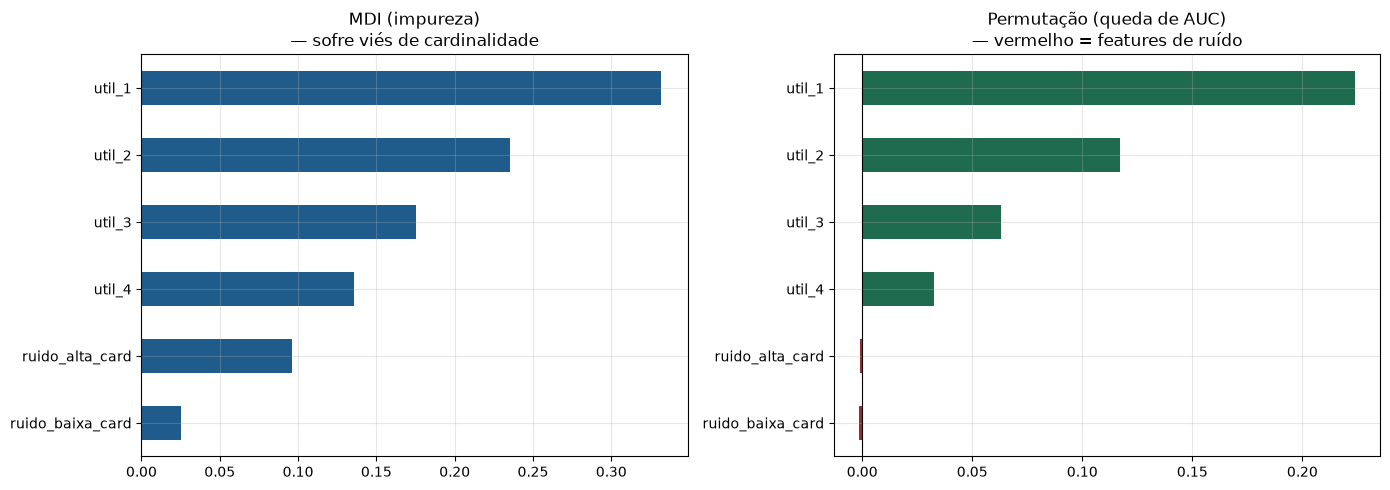

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importancia_mdi.plot(kind="barh", ax=axes[0], color=AZUL)
axes[0].set_title("MDI (impureza)\n— sofre viés de cardinalidade")
axes[0].invert_yaxis()

cores_permutacao = [VERMELHO if "ruido" in nome else VERDE
                    for nome in importancia_permutacao.index]
importancia_permutacao.plot(kind="barh", ax=axes[1], color=cores_permutacao)
axes[1].set_title("Permutação (queda de AUC)\n— vermelho = features de ruído")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

**A diferença deveria ficar visível:** MDI tende a colocar
`ruido_alta_card` numa posição artificialmente alta no ranking — mesmo
sendo puro ruído por construção. A importância por permutação, medida pela
queda real de desempenho no teste, tende a colocar as duas colunas de
ruído perto de zero (ou até negativas — permutar uma feature irrelevante
pode "melhorar" o score por acaso), enquanto as 4 features úteis mostram
quedas claramente positivas.

## 5. Um teste de sanidade final: remover as features de ruído muda o desempenho?

In [6]:
from sklearn.metrics import roc_auc_score

rf_com_ruido = RandomForestClassifier(n_estimators=300, random_state=0).fit(
    X_treino, y_treino)
rf_sem_ruido = RandomForestClassifier(n_estimators=300, random_state=0).fit(
    X_treino[["util_1", "util_2", "util_3", "util_4"]], y_treino)

auc_com_ruido = roc_auc_score(
    y_teste, rf_com_ruido.predict_proba(X_teste)[:, 1])
auc_sem_ruido = roc_auc_score(
    y_teste, rf_sem_ruido.predict_proba(X_teste[["util_1", "util_2", "util_3", "util_4"]])[:, 1])

print(f"AUC com as features de ruído incluídas: {auc_com_ruido:.4f}")
print(f"AUC sem as features de ruído          : {auc_sem_ruido:.4f}")
print("\nSe os números ficarem parecidos (dentro do ruído estatístico), isso")
print("confirma que 'ruido_alta_card' nunca carregou sinal real, apesar de")
print("aparecer alto no ranking de MDI.")

AUC com as features de ruído incluídas: 0.8990
AUC sem as features de ruído          : 0.9025

Se os números ficarem parecidos (dentro do ruído estatístico), isso
confirma que 'ruido_alta_card' nunca carregou sinal real, apesar de
aparecer alto no ranking de MDI.


## O que levar deste notebook

- O viés de cardinalidade da importância por MDI, já visto no tema 3 com
  uma única árvore, persiste (de forma mais sutil, mas ainda presente) em
  Random Forest — não é um artefato de árvores individuais isoladas.
- Importância por permutação, calculada em dados de validação/teste, não
  sofre desse viés — ela mede o efeito real no desempenho, não uma
  propriedade estrutural da feature.
- O teste definitivo de que uma feature importa é sempre o desempenho com
  e sem ela, medido honestamente — qualquer ranking de importância é um
  atalho para essa pergunta, não um substituto dela.

→ Próximo: o notebook de **exercícios** do módulo.